# setup

In [1]:
import os
import glob
import time
import fastf1
import logging
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
from datetime import datetime
import matplotlib.pyplot as plt
from IPython.display import display

# enable cache for fastf1 library
fastf1.Cache.enable_cache("cache")

# modify display settings
pd.set_option("display.max_rows", 200)  # allow scrolling
warnings.filterwarnings("ignore", category=FutureWarning)

# Pull data from fastf1 library

### get schedule for all years avaliable 
* only need to run once

In [2]:
# # initialize list to hold data
# all_schedules = []

# # iteratively get one year at a time
# for year in range(2018, 2027): 
#     try:
#         # get schedule
#         schedule = fastf1.get_event_schedule(year)
#         # uncomment if you want to save schedule by year
#         # schedule.to_csv(f"data/event_schedule_{year}.csv", index=False)

#         # add column for year and add schedule to list of schedules
#         temp = schedule.copy()
#         temp["Season"] = year
#         all_schedules.append(temp)
        
#         print(f"saved {year}")

#     except Exception as e:
#         print(f"skipping {year}: {e}")

# # join dataframes for all years together and save to csv
# full_schedule = pd.concat(all_schedules, ignore_index=True)
# full_schedule.to_csv("data/event_schedule.csv", index=False)

### get data by year
* need to pull in chunks because the API has a limit of 500 calls per hour

In [3]:
# # read saved schedule data
# schedule = pd.read_csv("data/event_schedule.csv")

# # adjust year
# year = 2026

# # filter schedule by year
# schedule["EventDate"] = pd.to_datetime(schedule["EventDate"])
# schedule = schedule[schedule["EventDate"].dt.year == year]

# # iterate over scheduled events
# for _, row in schedule.iterrows():
#     # get event name
#     event_name = row["EventName"]
#     event_date = row["EventDate"]

#     try:
#         # get data by year and event
#         session = fastf1.get_session(year, event_name, "Q")
#         session.load()

#         # get tables
#         laps = session.laps
#         results = session.results
#         weather = session.weather_data
        
#         # add event name and date to all tables
#         laps['EventName'] = event_name
#         laps['EventDate'] = event_date
#         results['EventName'] = event_name
#         results['EventDate'] = event_date
#         weather['EventName'] = event_name
#         weather['EventDate'] = event_date
         
#         fname = event_name.replace(" ", "_")
#         # save tables to data folder (save in chunks in case API limit is hit)
#         laps.to_csv(f"data/{year}_{fname}_laps.csv", index=False)
#         results.to_csv(f"data/{year}_{fname}_results.csv", index=False)
#         weather.to_csv(f"data/{year}_{fname}_weather.csv", index=False)

#         print(f"saved {event_name}")

#     except Exception as e:
#         print(f"skipped {event_name}: {e}")

### consolidate files into single file
* if run multiple times might create duplicates if a year had to be run more than once above

In [4]:
# file_groups = {"laps": glob.glob(os.path.join("data", "*_laps.csv")),
#                "results": glob.glob(os.path.join("data", "*_results.csv")),
#                "weather": glob.glob(os.path.join("data", "*_weather.csv"))}

# for kind, files in file_groups.items():
#     master_path = os.path.join(data_dir, f"all_{kind}.csv")
#     dfs = []
    
#     if os.path.exists(master_path):
#         dfs.append(pd.read_csv(master_path))

#     for f in files:
#         if os.path.abspath(f) == os.path.abspath(master_path):
#             continue
#         dfs.append(pd.read_csv(f))

#     combined = pd.concat(dfs, ignore_index=True)
#     combined.to_csv(master_path, index=False)

#     for f in files:
#         if os.path.abspath(f) != os.path.abspath(master_path):
#             os.remove(f)

#     print(f"consolidated {kind} into {master_path}")

### get throttle percentage data

In [5]:
# schedule = pd.read_csv("data/event_schedule.csv")
# schedule["EventDate"] = pd.to_datetime(schedule["EventDate"])

# rows = []

# for _, row in schedule.iterrows():
#     year = row["EventDate"].year
#     event_name = row["EventName"]
#     event_date = row["EventDate"]

#     session = fastf1.get_session(year, event_name, "Q")
#     session.load()
#     fastest_lap = session.laps.pick_fastest()
#     telemetry = fastest_lap.get_telemetry()
#     full_throttle_pct = (telemetry["Throttle"] >= 98).mean() * 100

#     rows.append({"Year": year, "EventName": event_name, "EventDate": event_date,
#                  "Driver": fastest_lap["Driver"], "Team": fastest_lap["Team"],
#                  "LapTime": fastest_lap["LapTime"], "FullThrottlePct": full_throttle_pct})
    
# throttle_df = pd.DataFrame(rows)
# throttle_df.to_csv("data/throttle_pct.csv", index=False)

# Data Cleaning and EDA 

In [6]:
# table that has mostly complete data
# lacks weather, circuit data
f1_teams = pd.read_csv("data/f1_teams_table.csv")

# table that has incomplete works & engine data
# but adds weather, throttle % data
modeling = pd.read_csv("data/modeling_table.csv")

### check number of duplicates

In [7]:
# count duplicates (full row)
print(f"f1_teams: has {f1_teams.duplicated().sum()} duplicate rows")
print(f"modeling: has {modeling.duplicated().sum()} duplicate rows")

f1_teams: has 46 duplicate rows
modeling: has 0 duplicate rows


In [8]:
# count duplicates in important columns (Year, EventName, DriverId) 
print("\nkey duplicates ")
print(f"f1_teams: has {f1_teams.duplicated(subset=['Year','EventName','DriverId']).sum()} duplicates in key columns")
print(f"modeling: has {modeling.duplicated(subset=['Year','EventName','DriverId']).sum()} duplicates in key columns")


key duplicates 
f1_teams: has 46 duplicates in key columns
modeling: has 0 duplicates in key columns


In [9]:
# drop duplicates
f1_teams_unique = f1_teams.drop_duplicates(subset=["Year", "EventName", "DriverId"], keep="first")

### check for missing data

In [10]:
# count f1_teams NAs
print(f"f1_teams: has {f1_teams.isna().sum().sum()} NA cells")

f1_teams_na = (f1_teams.isna()
                       .sum()
                       .reset_index(name="missing_count")
                       .rename(columns={"index": "column"})
                       .assign(missing_pct=lambda x: (x["missing_count"] / len(f1_teams) * 100).round(2))
                       .sort_values("missing_count", ascending=False))

display(f1_teams_na.style.background_gradient(subset=["missing_count"], cmap="Reds"))

f1_teams: has 96 NA cells


,column,missing_count,missing_pct
6,Q1time,96,1.880000
0,Year,0,0.000000
1,EventName,0,0.000000
2,DriverId,0,0.000000
3,TeamName,0,0.000000
4,engine,0,0.000000
5,works,0,0.000000


In [11]:
# count modeling NAs
print(f"modeling: has {modeling.isna().sum().sum()} NA cells")

modeling_na = (modeling.isna()
                       .sum()
                       .reset_index(name="missing_count")
                       .rename(columns={"index": "column"})
                       .assign(missing_pct=lambda x: (x["missing_count"] / len(modeling) * 100).round(2))
                       .sort_values("missing_count", ascending=False))

display(modeling_na.style.background_gradient(subset=["missing_count"], cmap="Reds"))

modeling: has 2268 NA cells


,column,missing_count,missing_pct
6,engine,1132,31.350000
7,works,1132,31.350000
3,Rainfall,4,0.110000
0,Year,0,0.000000
1,EventName,0,0.000000
2,FullThrottlePct,0,0.000000
4,DriverId,0,0.000000
5,TeamName,0,0.000000
8,Q1_time,0,0.000000


#### we want to double check which Q1 times are missing in f1_teams

In [12]:
# filter missing Q1time
f1_teams_NA = f1_teams_unique[f1_teams_unique["Q1time"].isna()]

# count by Year + EventName
f1_teams_NA_event_summary = (f1_teams_NA.groupby(["Year", "EventName"]).size()
                                        .reset_index(name="Q1 missing count")
                                         .sort_values(["Year", "EventName"]))

display(f1_teams_NA_event_summary.style.background_gradient(subset=["Q1 missing count"], cmap="Reds"))

,Year,EventName,Q1 missing count
0,2014,Abu Dhabi Grand Prix,2
1,2014,Australian Grand Prix,1
2,2014,Canadian Grand Prix,1
3,2014,Chinese Grand Prix,1
4,2014,German Grand Prix,1
5,2014,Hungarian Grand Prix,2
6,2014,Spanish Grand Prix,1
7,2015,Bahrain Grand Prix,1
8,2015,Brazilian Grand Prix,1
9,2015,Canadian Grand Prix,1


2020 sakhir grand prix seems to be missing. the event did happen, so there's some error/quality issues in our data.

#### we want to check difference in number of events between modeling and f1_teams

In [13]:
# count events per year in each dataset
f1_counts = (f1_teams_unique.groupby(["Year", "EventName"])
               .size().reset_index(name="n")
               .groupby("Year").size()
               .reset_index(name="f1_teams event count"))

modeling_counts = (modeling.groupby(["Year", "EventName"])
                     .size().reset_index(name="n")
                   .groupby("Year").size().reset_index(name="modeling event count"))

# merge counts together
event_comparison = f1_counts.merge(modeling_counts, on="Year", how="outer").sort_values("Year")

# format counts
event_comparison = event_comparison.fillna(0).astype({"f1_teams event count": int,
                                                      "modeling event count": int})

display(event_comparison.style.background_gradient(subset=["f1_teams event count", "modeling event count"], cmap="Blues"))

,Year,f1_teams event count,modeling event count
0,2014,19,0
1,2015,19,0
2,2016,21,0
3,2017,20,0
4,2018,21,21
5,2019,21,21
6,2020,17,19
7,2021,21,23
8,2022,22,24
9,2023,22,23


#### we want to check for missing events in f1_teams

In [14]:
# count by Year + EventName
f1_event_summary = (f1_teams_unique.groupby(["Year", "EventName"]).size()
                                  .reset_index(name="Count")
                                  .sort_values(["Year", "EventName"]))

display(f1_event_summary.style.background_gradient(subset=["Count"], cmap="Greens"))

,Year,EventName,Count
0,2014,Abu Dhabi Grand Prix,20
1,2014,Australian Grand Prix,22
2,2014,Austrian Grand Prix,22
3,2014,Bahrain Grand Prix,22
4,2014,Belgian Grand Prix,22
5,2014,Brazilian Grand Prix,18
6,2014,British Grand Prix,22
7,2014,Canadian Grand Prix,22
8,2014,Chinese Grand Prix,22
9,2014,German Grand Prix,22


#### we want to check for missing events in modeling

In [15]:
# count by Year + EventName
modeling_event_summary = (modeling.groupby(["Year", "EventName"]).size()
                                  .reset_index(name="Count")
                                  .sort_values(["Year", "EventName"]))

display(modeling_event_summary.style.background_gradient(subset=["Count"], cmap="Greens"))

,Year,EventName,Count
0,2018,Abu Dhabi Grand Prix,20
1,2018,Australian Grand Prix,20
2,2018,Austrian Grand Prix,20
3,2018,Azerbaijan Grand Prix,19
4,2018,Bahrain Grand Prix,20
5,2018,Belgian Grand Prix,20
6,2018,Brazilian Grand Prix,20
7,2018,British Grand Prix,18
8,2018,Canadian Grand Prix,19
9,2018,Chinese Grand Prix,20


In [16]:
# keep only actual races
modeling = modeling[modeling["EventName"].str.contains("Prix", na=False)]

# remove races from current ongoing year
modeling = modeling[modeling["Year"] < 2026]

### generated columns and do fill-ins

#### create labels for weather data at the event level

In [17]:
# create function to map label for event
def classify_session(x):
    vals = {str(v).strip().lower() for v in x.dropna()}
    if len(vals) == 0:
        return "no data"
    if len(vals) > 1:
        return "mixed"
    if vals == {"true"}:
        return "wet"
    if vals == {"false"}:
        return "dry"
    return "error"

# fill in nulls for rows missing rainfall  
modeling["Rainfall"] = modeling["Rainfall"].replace("", np.nan)

# map labels to event
session_conditions = (modeling.groupby(["Year", "EventName"])["Rainfall"]
                        .apply(classify_session)
                        .reset_index(name="SessionCondition"))

# join labels back to modeling
modeling_SC = modeling.merge(session_conditions, on=["Year", "EventName"], how="left")

#### get missing engine and works data from f1_teams and add it to modeling

In [18]:
# select relevant columns
modeling_SC = modeling_SC[['Year', 'EventName', 'TeamName', 'DriverId', 'SessionCondition', 
                           'FullThrottlePct', 'Q1_time']]

# build lookup from f1_teams
lookup = (f1_teams_unique[["Year", "DriverId", "engine", "works"]]
          .drop_duplicates(subset=["Year", "DriverId"]))

# join engine and works data to modeling
modeling_full = modeling_SC.merge(lookup, on=["Year", "DriverId"], how="left")

In [19]:
# recheck missing counts
print(f"modeling_full: has {modeling_full.isna().sum().sum()} NA cells")

modeling_full_na = (modeling_full.isna().sum().reset_index(name="missing_count")
                      .rename(columns={"index": "column"})
                    .assign(missing_pct=lambda x: (x["missing_count"] / len(modeling_full) * 100).round(2))
                    .sort_values("missing_count", ascending=False))

display(modeling_full_na.style.background_gradient(subset=["missing_count"], cmap="Reds"))

modeling_full: has 0 NA cells


,column,missing_count,missing_pct
0,Year,0,0.000000
1,EventName,0,0.000000
2,TeamName,0,0.000000
3,DriverId,0,0.000000
4,SessionCondition,0,0.000000
5,FullThrottlePct,0,0.000000
6,Q1_time,0,0.000000
7,engine,0,0.000000
8,works,0,0.000000


### EDA and Assumption Checks

#### summary statistics and visualizations for numeric variables

In [20]:
display(modeling_full.describe().round(2))

,Year,FullThrottlePct,Q1_time,works
count,3412.00,3412.00,3412.00,3412.00
mean,2021.65,61.12,85.24,0.42
std,2.31,8.82,12.41,0.49
min,2018.00,32.86,53.90,0.00
25%,2020.00,56.41,76.48,0.00
50%,2022.00,62.22,84.32,0.00
75%,2024.00,67.16,92.65,1.00
max,2025.00,76.55,141.61,1.00


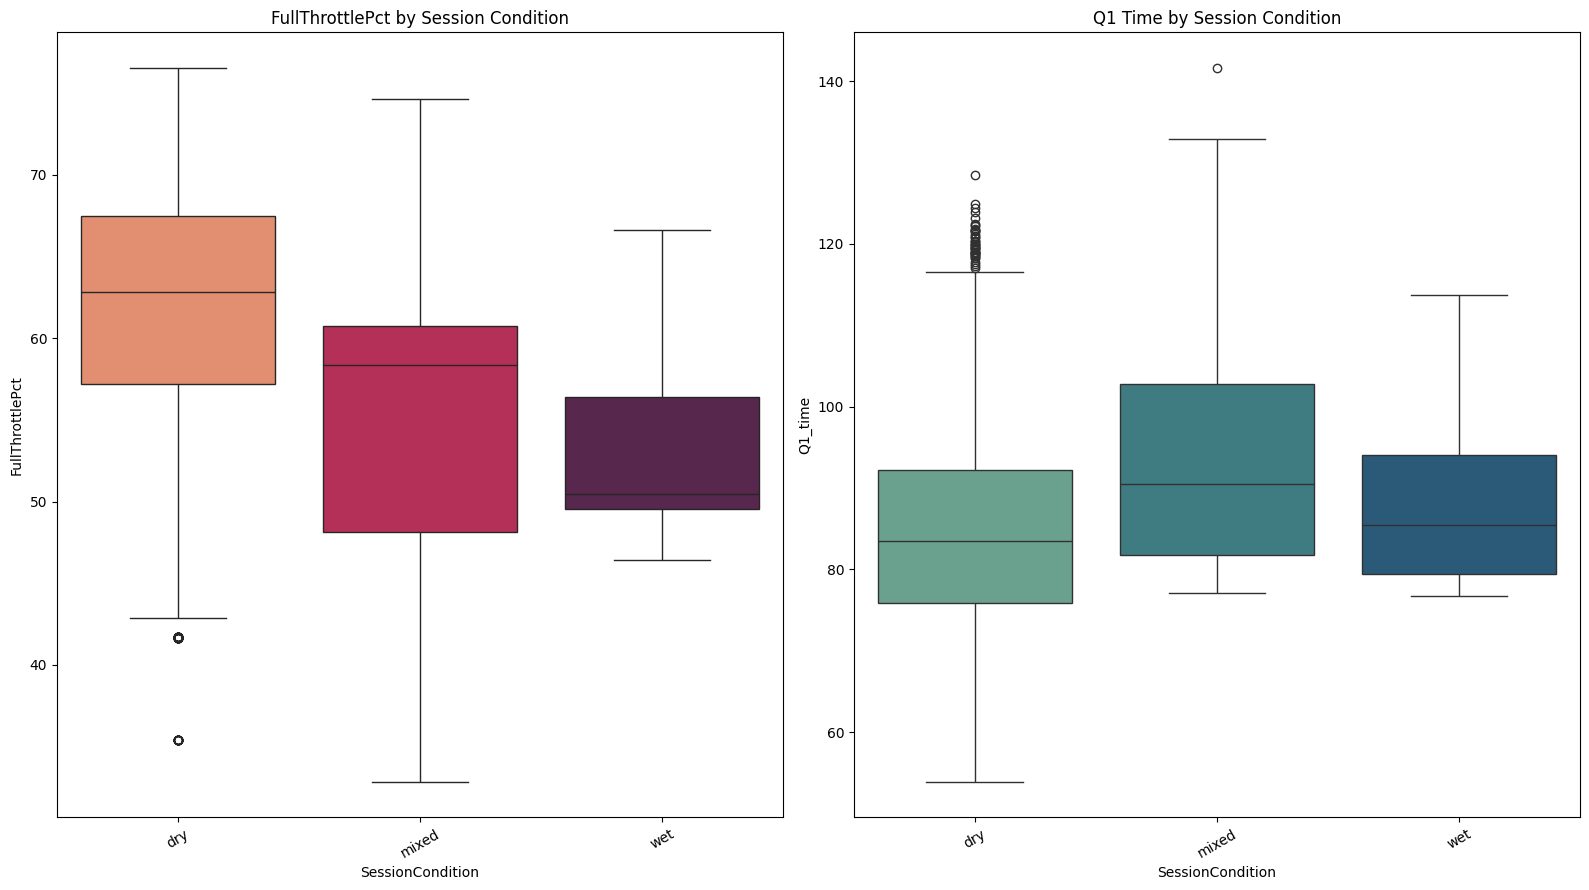

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# FullThrottlePct broken out by weather 
sns.boxplot(data=modeling_full, x="SessionCondition", y="FullThrottlePct", ax=axes[0], palette="rocket_r")
axes[0].set_title("FullThrottlePct by Session Condition")
axes[0].tick_params(axis='x', rotation=30)

# Q1_time  broken out by weather 
sns.boxplot(data=modeling_full, x="SessionCondition", y="Q1_time", ax=axes[1], palette="crest")
axes[1].set_title("Q1 Time by Session Condition")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

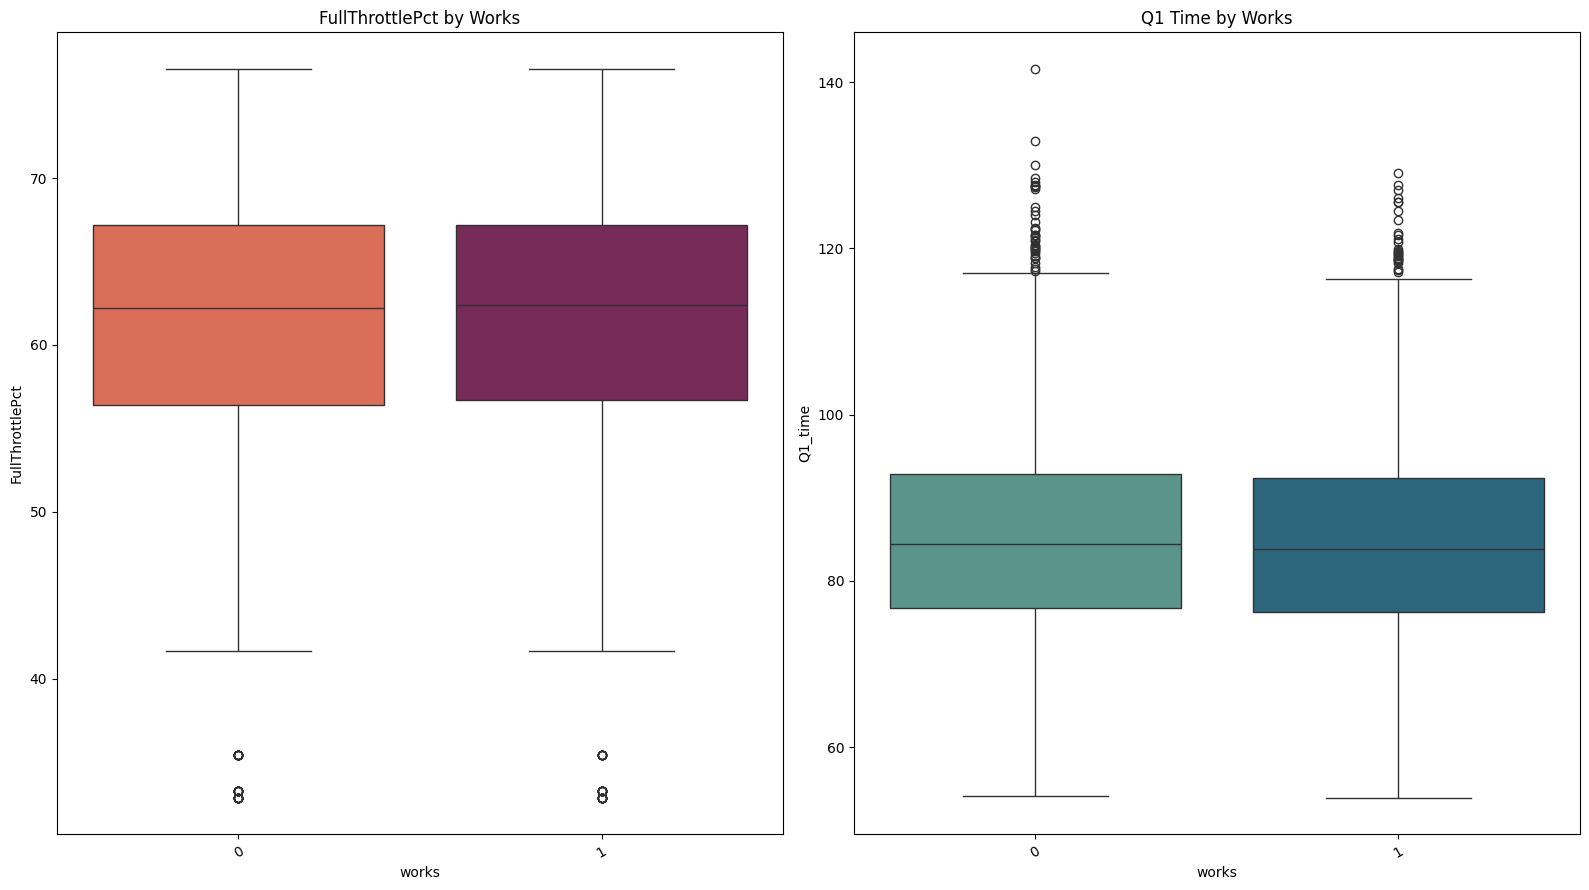

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# FullThrottlePct broken out by work 
sns.boxplot(data=modeling_full, x="works", y="FullThrottlePct", ax=axes[0], palette="rocket_r")
axes[0].set_title("FullThrottlePct by Works")
axes[0].tick_params(axis='x', rotation=30)

# Q1_time  broken out by work 
sns.boxplot(data=modeling_full, x="works", y="Q1_time", ax=axes[1], palette="crest")
axes[1].set_title("Q1 Time by Works")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

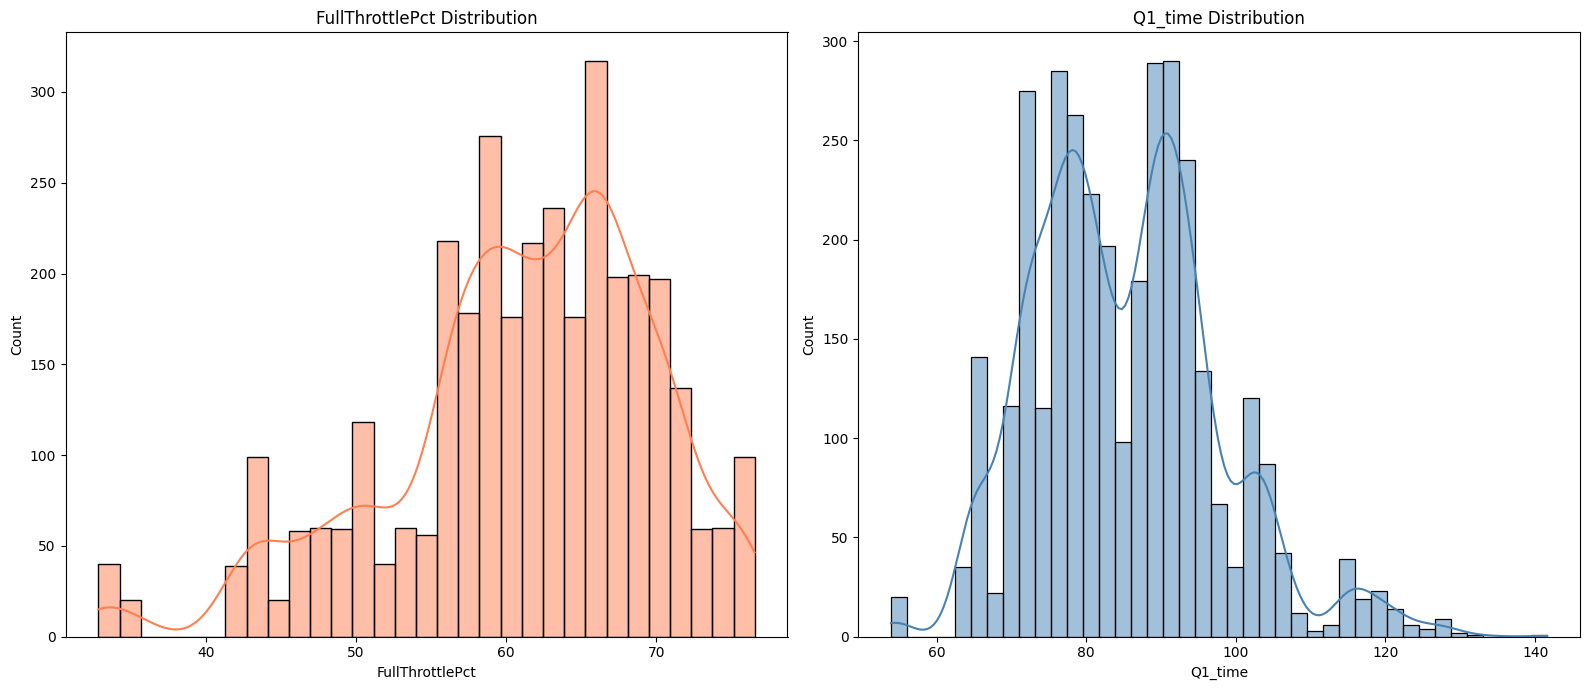

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.histplot(modeling_full["FullThrottlePct"], kde=True, ax=axes[0], color="coral")
axes[0].set_title("FullThrottlePct Distribution")

sns.histplot(modeling_full["Q1_time"], kde=True, ax=axes[1], color="steelblue")
axes[1].set_title("Q1_time Distribution")

plt.tight_layout()
plt.show()

#### summary statistics and visualizations for categorical variables

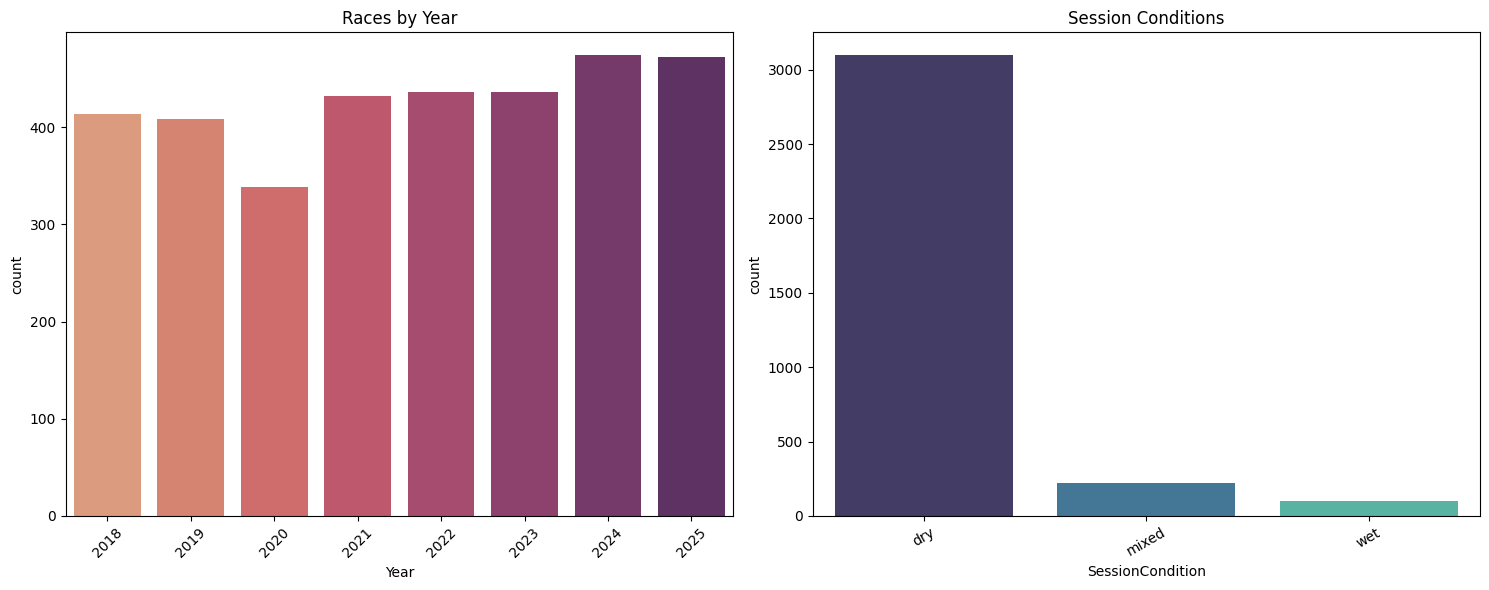

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.countplot(data=modeling_full, x="Year", ax=axes[0], palette="flare")
axes[0].set_title("Races by Year")
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=modeling_full, x="SessionCondition", ax=axes[1], palette="mako")
axes[1].set_title("Session Conditions")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

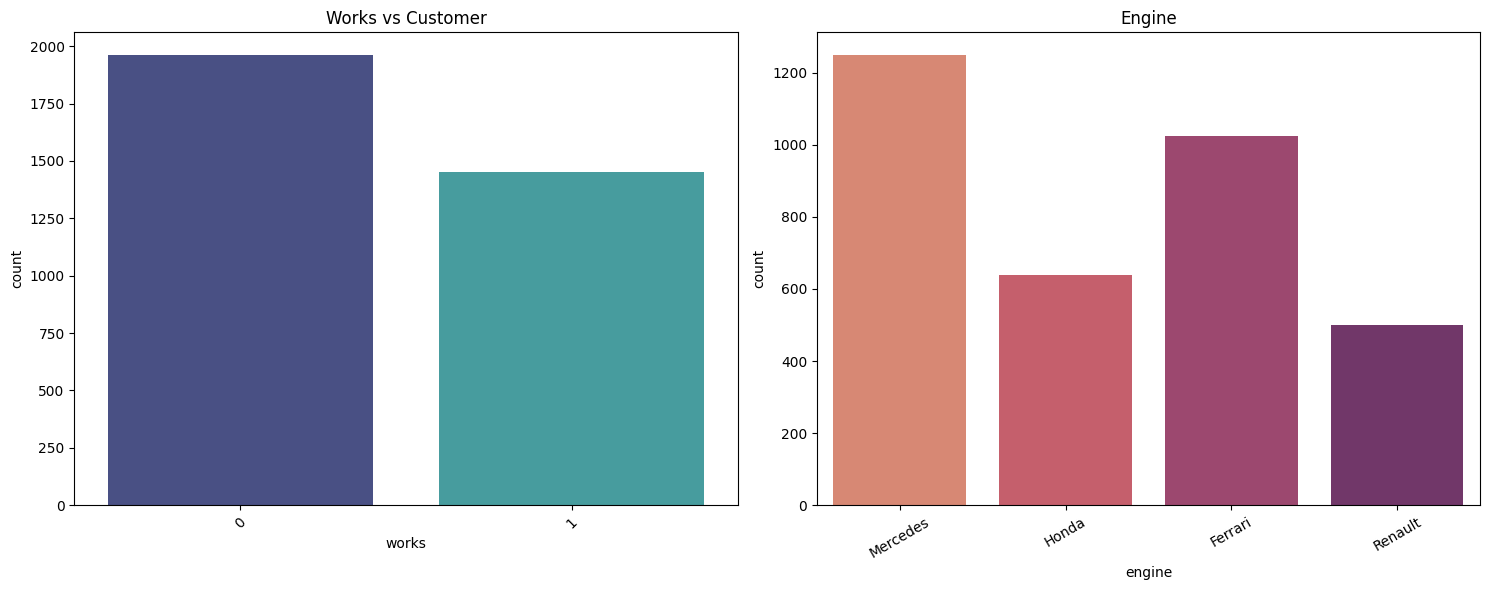

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.countplot(data=modeling_full, x="engine", ax=axes[1], palette="flare")
axes[1].set_title("Engine")
axes[1].tick_params(axis='x', rotation=30)

sns.countplot(data=modeling_full, x="works", ax=axes[0], palette="mako")
axes[0].set_title("Works vs Customer")
axes[0].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [26]:
# restrict data to races without any rain
modeling_full = modeling_full[modeling_full["SessionCondition"] == "dry"]

#### variance check

In [27]:
groups = [g["Q1_time"].values for _, g in modeling_full.groupby("works")]
print("Levene (works):", stats.levene(*groups).pvalue)

Levene (works): 0.6911549517131338


no evidence of unequal variance

In [28]:
groups = [g["Q1_time"].values for _, g in modeling_full.groupby("engine")]
print("Levene (engine):", stats.levene(*groups).pvalue)

Levene (engine): 0.9649981127576663


no evidence of unequal variance

#### correlation heatmap

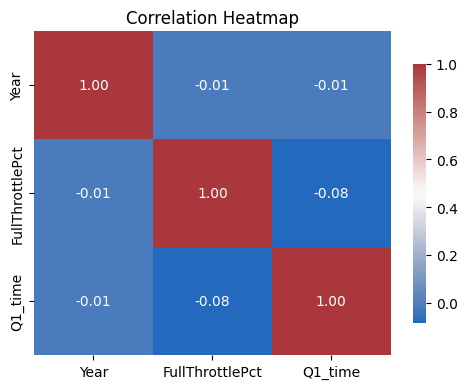

In [29]:
plt.figure(figsize=(5, 4))

sns.heatmap(modeling_full[["Year", "FullThrottlePct", "Q1_time"]].corr(), annot=True, cmap="vlag",
               fmt=".2f", annot_kws={"size": 10}, cbar_kws={"shrink": 0.8})

plt.title("Correlation Heatmap", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

### Write Out Data

In [30]:
modeling_full.to_csv("data/modeling_processed.csv", index=False)